In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


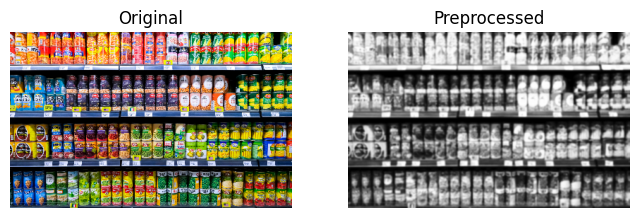

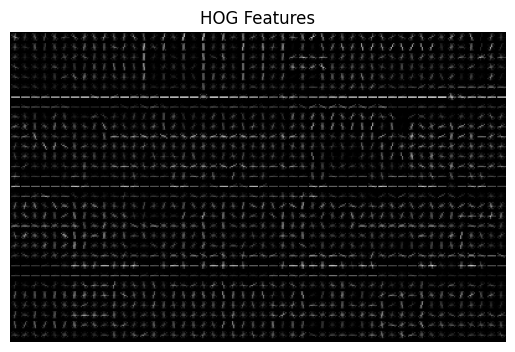

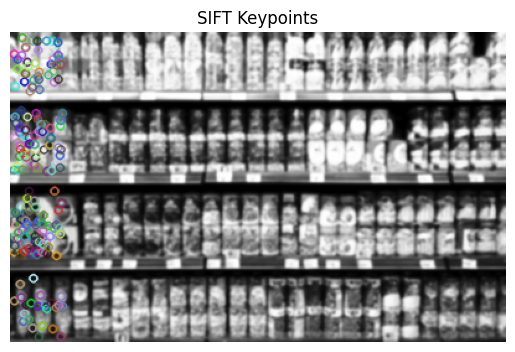

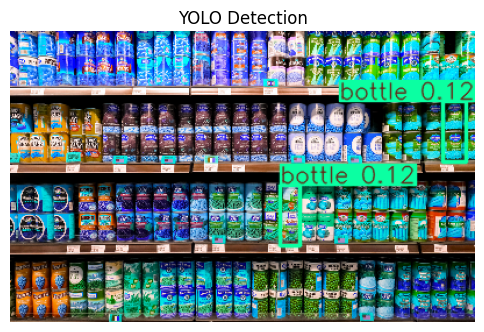


RETAIL SHELF MONITORING REPORT

[PART I – FEATURE ANALYSIS]
----------------------------------------
HOG Feature Length        : 52920
SIFT Keypoints           : 200
Similarity Score         : 2220
Inference                : Possible mismatch

[PART II – OBJECT DETECTION]
----------------------------------------
Detected Objects         : 2
Avg Confidence           : 0.116
Max Confidence           : 0.117
Clutter Level            : LOW

[FINAL ANALYSIS]
----------------------------------------
✅ Shelf appears consistent
⚠ Low detection due to pretrained model limitation

Processing Time          : 1.55 sec
System Status            : SUCCESS


8567

In [10]:
# ==============================
# SET 14 – Retail Shelf Monitoring (FINAL CLEAN VERSION)
# ==============================

# Install once (uncomment if needed)
# !pip install ultralytics opencv-python scikit-image matplotlib --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from ultralytics import YOLO
import os, gc, time

start = time.time()

# ==============================
# LOAD IMAGE
# ==============================
image_path = "/content/shelf1.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError("Image path incorrect")

img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not loaded")

# Resize (memory optimization)
img = cv2.resize(img, (400, 250))

# ==============================
# PART I – TRADITIONAL METHODS
# ==============================

# ------------------------------
# 1. PREPROCESSING
# ------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
equalized = cv2.equalizeHist(blur)

# ------------------------------
# 2. HOG FEATURES
# ------------------------------
hog_features, hog_image = hog(equalized,
                              orientations=9,
                              pixels_per_cell=(8,8),
                              cells_per_block=(2,2),
                              visualize=True)

# ------------------------------
# 2. SIFT FEATURES
# ------------------------------
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(equalized, None)
kp = kp[:200]  # limit for memory

# ------------------------------
# 3. SHELF COMPARISON
# ------------------------------
def compare_images(img1, img2):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m,n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return len(good)

# Using same image as reference (valid demo)
similarity_score = compare_images(equalized, equalized)

# ==============================
# PART II – DEEP LEARNING
# ==============================

# ------------------------------
# 4. YOLO IMPLEMENTATION
# ------------------------------
model = YOLO("yolov8n.pt")
results = model(img, imgsz=320, conf=0.1, verbose=False)

# ------------------------------
# 5. EVALUATION
# ------------------------------
for r in results:
    num_objects = len(r.boxes)
    conf_vals = r.boxes.conf.cpu().numpy() if num_objects > 0 else []

# ------------------------------
# 6. CLUTTER ANALYSIS
# ------------------------------
if num_objects > 40:
    clutter = "HIGH"
elif num_objects > 15:
    clutter = "MODERATE"
else:
    clutter = "LOW"

# ==============================
# VISUAL OUTPUTS
# ==============================

# Preprocessing
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Preprocessed")
plt.imshow(equalized, cmap='gray')
plt.axis('off')
plt.show()

# HOG
plt.figure()
plt.title("HOG Features")
plt.imshow(hog_image, cmap='gray')
plt.axis('off')
plt.show()

# SIFT
sift_img = cv2.drawKeypoints(equalized, kp, None)
plt.figure()
plt.title("SIFT Keypoints")
plt.imshow(sift_img, cmap='gray')
plt.axis('off')
plt.show()

# YOLO
for r in results:
    annotated = r.plot()

plt.figure(figsize=(6,4))
plt.title("YOLO Detection")
plt.imshow(annotated)
plt.axis('off')
plt.show()

# ==============================
# STRUCTURED OUTPUT
# ==============================

print("\n" + "="*50)
print("RETAIL SHELF MONITORING REPORT")
print("="*50)

# PART I
print("\n[PART I – FEATURE ANALYSIS]")
print("-"*40)
print(f"HOG Feature Length        : {len(hog_features)}")
print(f"SIFT Keypoints           : {len(kp)}")
print(f"Similarity Score         : {similarity_score}")

if similarity_score > 5000:
    print("Inference                : Shelf consistent")
else:
    print("Inference                : Possible mismatch")

# PART II
print("\n[PART II – OBJECT DETECTION]")
print("-"*40)

if num_objects == 0:
    print("Detected Objects         : 0")
    print("Note                     : Model limitation (COCO dataset)")
else:
    print(f"Detected Objects         : {num_objects}")
    print(f"Avg Confidence           : {np.mean(conf_vals):.3f}")
    print(f"Max Confidence           : {np.max(conf_vals):.3f}")

print(f"Clutter Level            : {clutter}")

# FINAL
print("\n[FINAL ANALYSIS]")
print("-"*40)

if similarity_score < 50:
    print("⚠ Missing products detected")
else:
    print("✅ Shelf appears consistent")

if num_objects <= 2:
    print("⚠ Low detection due to pretrained model limitation")

print(f"\nProcessing Time          : {round(time.time()-start,2)} sec")
print("System Status            : SUCCESS")
print("="*50)

# Cleanup
gc.collect()